<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); color: white; padding: 30px; border-radius: 15px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; text-align: center; box-shadow: 0 10px 20px rgba(0,0,0,0.19), 0 6px 6px rgba(0,0,0,0.23);">
    <div style="font-size: 50px; margin-bottom: 10px;"> 📖</div>
    <h1 style="margin: 0; font-size: 36px; text-shadow: 2px 2px 4px rgba(0,0,0,0.3);">
        Tox21: Exploration Data Analisys
    </h1>
    <p style="font-size: 18px; margin-top: 5px; font-weight: 300;">
        Exploring data distributions, class imbalance, and missing values     
</p>

<p style="font-size: 16px; margin-top: 10px; font-weight: 300; line-height: 1.5;">
    The notebook is structured as follows: <br>
     <strong>Imports</strong> |  <strong>Overview</strong> |  <strong>First Check</strong> |  <strong>Deeper Analisy</strong> |  <strong>Extra</strong></p>
</div>

# **Imports**
---

In [ ]:
# Standard libraries
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import plotly.express as px
import py3Dmol
from sklearn.manifold import TSNE
from rdkit import Chem
from rdkit.Chem import Descriptors, AllChem
import kagglehub
from kagglehub import KaggleDatasetAdapter
from src.EDA.config import DATASET_PATH, RESULTS_PATH

#%matplotlib widget

# **Tox21: overview**
---




This dataset contains results of toxicity measurements on 12 biological targets, including nuclear receptors and stress response pathways.
For each molecule, 12 different entries are provided with two possible values: 0 if the test is false (no toxicity) or 1 otherwise (toxicity found).
The 12 tests are the following:
1) Nuclear Receptors (NR): Endocrine Disruptor Assays
    - NR-**AR** – Activation of the full-length androgen receptor
    - NR-**AR-LBD** – Activation of the androgen receptor ligand-binding domain
    - NR-**AhR** – Activation of the aryl hydrocarbon receptor
    - NR-**Aromatase** – Inhibition of aromatase activity
    - NR-**ER** – Activation of the full-length estrogen receptor
    - NR-**ER-LBD** – Activation of the estrogen receptor ligand-binding domain
    - NR-**PPAR-gamma** – Activation of the PPAR-gamma nuclear receptor


2) Stress Response (SR): Cellular Damage Assays
    - SR-**ARE** – Activation of the antioxidant response element (oxidative stress)
    - SR-**ATAD5** – Genotoxicity measured via ATAD5 induction
    - SR-**HSE** – Heat shock response activation
    - SR-**MMP** – Disruption of mitochondrial membrane potential
    - SR-**p53** – Activation of the p53 pathway in response to DNA damage

# **First Check**
---


## Dimension
Simply checking entries of the dataset

In [2]:
tox21_df = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS,"epicskills/tox21-dataset","tox21.csv")


print("Dataset's shape",tox21_df.shape)
target_cols=[col for col in tox21_df.columns if col.startswith(('NR-', 'SR-'))]
n_colums_test=tox21_df.shape[1]-2
index_col=[i for i in range(0,n_colums_test)]
cmap = plt.get_cmap("nipy_spectral") 
colors = [cmap(i) for i in np.linspace(0.05, 0.95,n_colums_test)]

Dataset's shape (7831, 14)


## Valid tests
For each Tox21 biological test, we compute the number of molecules with valid (non-missing) labels.

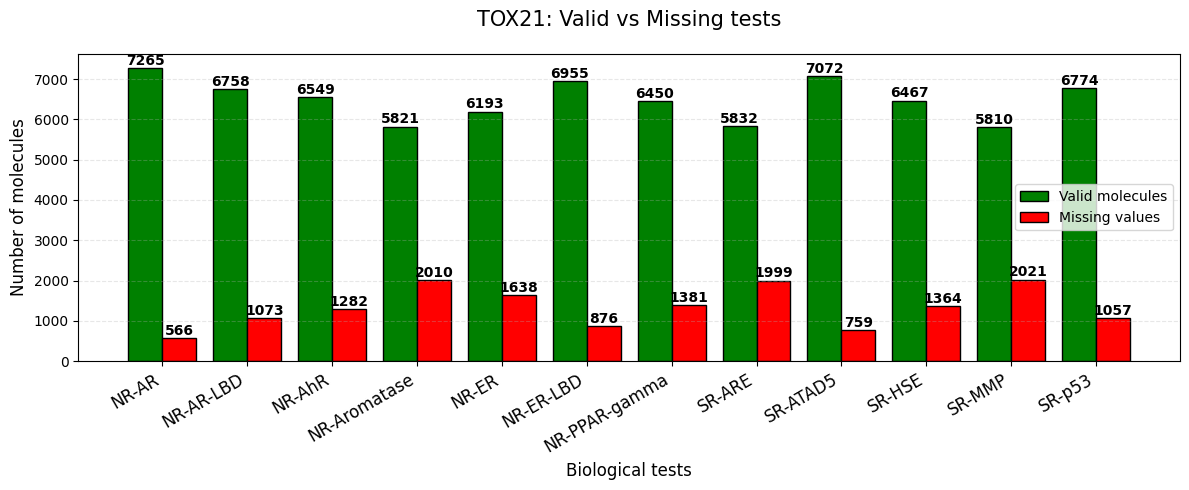

In [ ]:

# data
valid_molecule = tox21_df.shape[0] - tox21_df[target_cols].isnull().sum()
Nan_values = tox21_df[target_cols].isnull().sum()

x = np.arange(len(target_cols))  
width = 0.4  

plt.figure(figsize=(12,5))

# bars
plt.bar(x - width/2, valid_molecule, width, label='Valid molecules', color='green', edgecolor='black')
plt.bar(x + width/2, Nan_values, width, label='Missing values', color='red', edgecolor='black')

# labels
plt.xticks(x, target_cols, rotation=30, ha='right', fontsize=12)
plt.ylabel('Number of molecules', fontsize=12)
plt.xlabel('Biological tests', fontsize=12)
plt.title('TOX21: Valid vs Missing tests', fontsize=15, pad=20)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.legend()

# annotations
for i in range(len(target_cols)):
    plt.text(x[i] - width/2, valid_molecule.iloc[i]+5, f'{valid_molecule.iloc[i]}', ha='center', va='bottom', fontweight='bold')
    plt.text(x[i] + width/2, Nan_values.iloc[i]+5, f'{Nan_values.iloc[i]}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
#plt.savefig(f"{RESULTS_PATH}/validVSmissing.pdf", format="pdf", bbox_inches="tight")
plt.show()


## Toxic Molecules
Here, we show how many molecules are classified as toxic in each of the 12 tests.

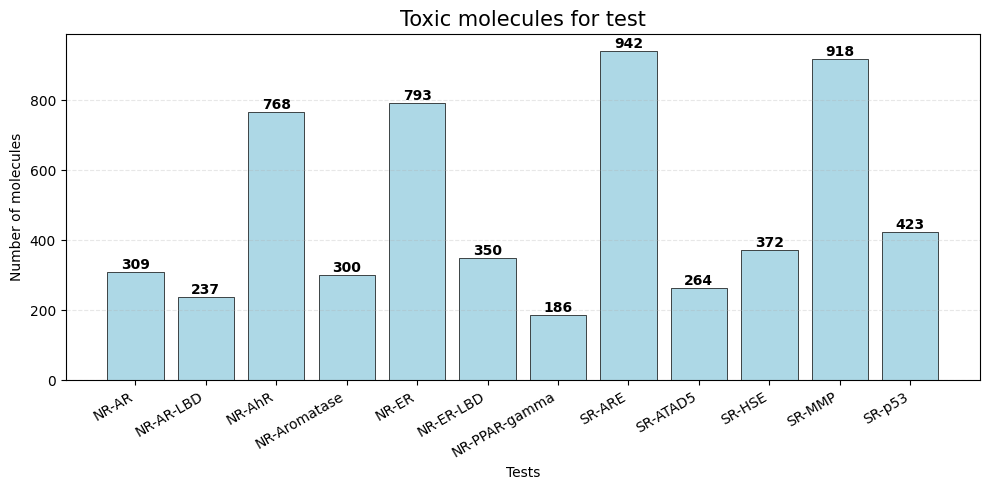

In [ ]:

num_molecules_toxicity = []

for col in target_cols:
    num_tox = tox21_df[col] == 1.0
    num_molecules_toxicity.append(num_tox.sum())


plt.figure(figsize=(10,5))
plt.bar(target_cols,num_molecules_toxicity,color="lightblue",edgecolor='black' ,linewidth=0.5)
plt.title('Toxic molecules for test', fontsize=15)
plt.xlabel('Tests')
plt.ylabel('Number of molecules')
plt.xticks(rotation=30, ha='right')

for i,v in enumerate(num_molecules_toxicity):
    plt.text(i, v , f'{v}', color='black', ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
#plt.savefig(f"{RESULTS_PATH}/molecules_foreach_toxicity.pdf", format="pdf", bbox_inches="tight")
plt.show()


# **Deeper Analisy**
---

## Class Imbalance
As we can look into the next section, this dataset contains much more safe molecules than toxic ones. The class unbalance is then combined with the toxicity unbalance, and a useful visualization (that takes into account both) is shown in the third bar-graph of this seciton.

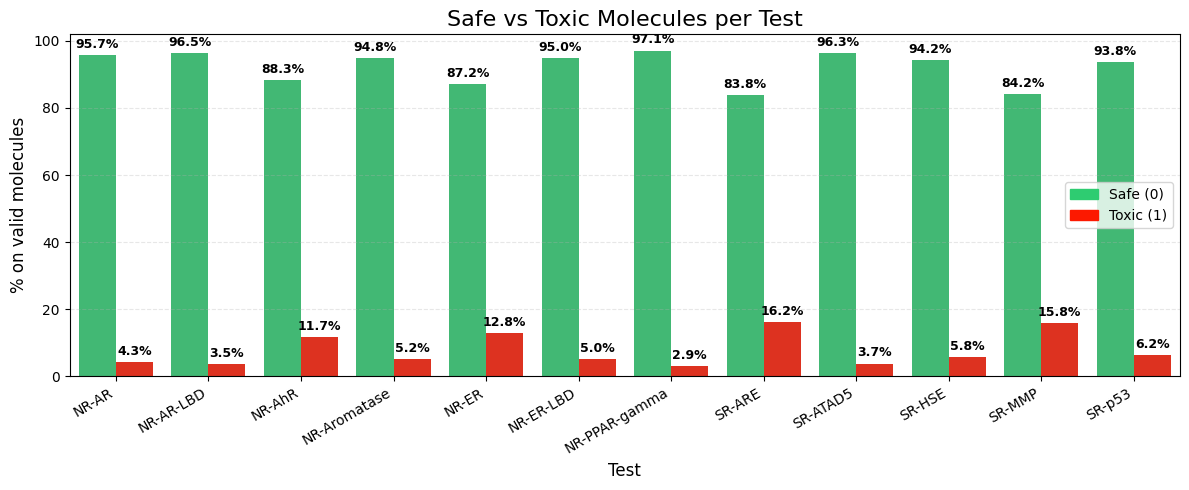

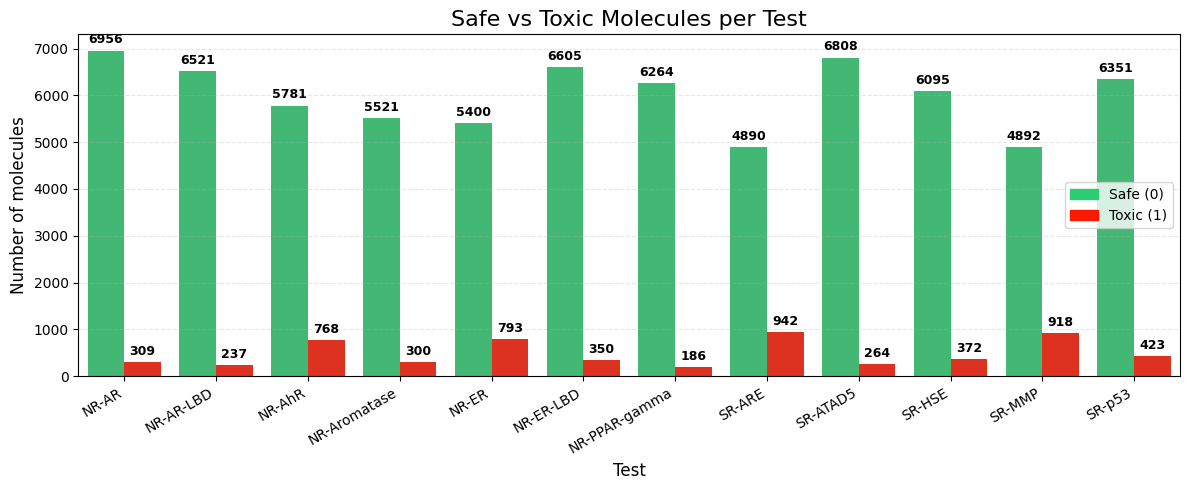

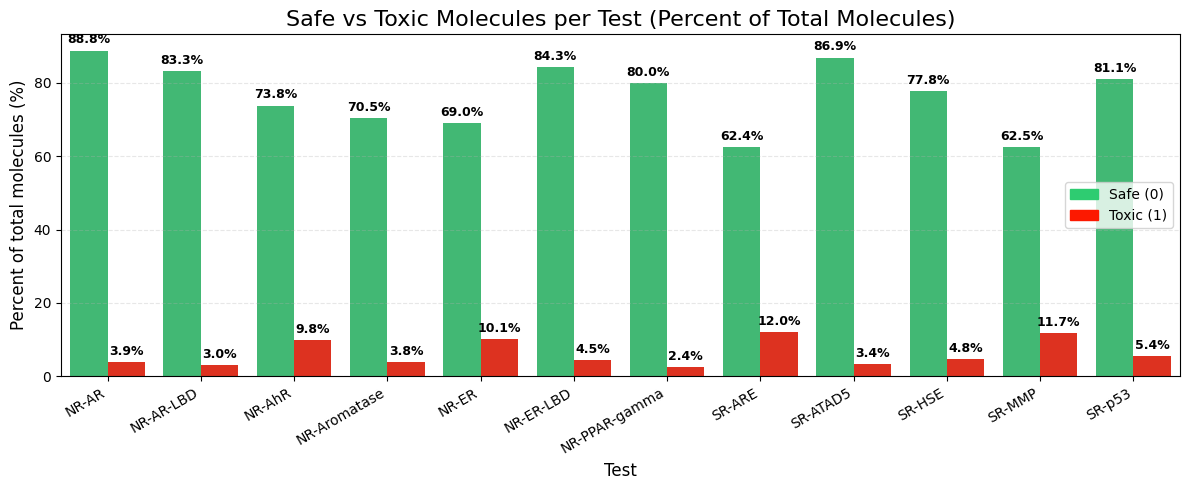

In [ ]:

melted_tox21 = tox21_df[target_cols].melt(var_name="Test", value_name="Esito")
df_melted = melted_tox21.dropna()

percent_df = (
    df_melted.groupby('Test')['Esito']
    .value_counts(normalize=True)   
    .rename('Percent')              
    .reset_index()
)
percent_df['Percent'] *= 100  

plt.figure(figsize=(12,5))
ax1 = sns.barplot(
    data=percent_df,
    x='Test',
    y='Percent',
    hue='Esito',
    palette={0.0: "#2ecc71", 1.0: "#fc1900"}
)
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.1f%%', padding=3, fontsize=9, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.title('Safe vs Toxic Molecules per Test', fontsize=16)
plt.xlabel('Test', fontsize=12)
plt.ylabel('% on valid molecules', fontsize=12)
safe_patch = mpatches.Patch(color="#2ecc71", label="Safe (0)")
toxic_patch = mpatches.Patch(color="#fc1900", label="Toxic (1)")
plt.legend(handles=[safe_patch, toxic_patch], title='', loc='center right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
#plt.savefig(f"{RESULTS_PATH}/safeVStoxic1.pdf", format="pdf", bbox_inches="tight")
plt.show()

plt.figure(figsize=(12,5))
ax2 = sns.countplot(
    data=df_melted,
    x='Test',
    hue='Esito',
    palette={0.0: "#2ecc71", 1.0: "#fc1900"}
)
for container in ax2.containers:
    ax2.bar_label(container, padding=3, fontsize=9, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.title('Safe vs Toxic Molecules per Test', fontsize=16)
plt.xlabel('Test', fontsize=12)
plt.ylabel('Number of molecules', fontsize=12)
plt.legend(handles=[safe_patch, toxic_patch], title='', loc='center right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
#plt.savefig(f"{RESULTS_PATH}/safeVStoxic2.pdf", format="pdf", bbox_inches="tight")
plt.show()

total_molecules = tox21_df.shape[0]
percent_total_df = (
    df_melted.groupby('Test')['Esito']
    .value_counts()               
    .rename('Count')
    .reset_index()
)
percent_total_df['PercentTotal'] = percent_total_df['Count'] / total_molecules * 100

plt.figure(figsize=(12,5))
ax3 = sns.barplot(
    data=percent_total_df,
    x='Test',
    y='PercentTotal',
    hue='Esito',
    palette={0.0: "#2ecc71", 1.0: "#fc1900"}
)
for container in ax3.containers:
    ax3.bar_label(container, fmt='%.1f%%', padding=3, fontsize=9, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.title('Safe vs Toxic Molecules per Test (Percent of Total Molecules)', fontsize=16)
plt.xlabel('Test', fontsize=12)
plt.ylabel('Percent of total molecules (%)', fontsize=12)
plt.legend(handles=[safe_patch, toxic_patch], title='', loc='center right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
#plt.savefig(f"{RESULTS_PATH}/safeVStoxic3.pdf", format="pdf", bbox_inches="tight")
plt.show()


## Tests' correlation
Here we check if there is correlation between different tossicity tests. Just a couple of relations are present.

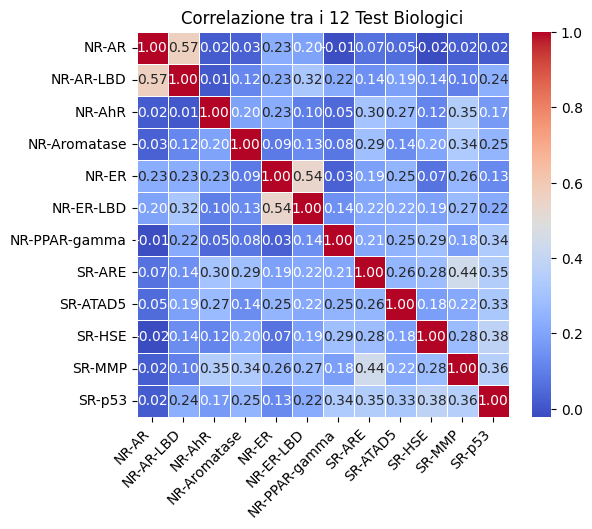

In [ ]:
plt.figure(figsize=(6,5))
corr = tox21_df[target_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlazione tra i 12 Test Biologici')
plt.xticks(rotation=45, ha='right')
#plt.savefig(f"{RESULTS_PATH}/toxic_correlation.pdf", format="pdf", bbox_inches="tight")
plt.show()

## Number of toxicity
Checking the number of molecules with n-toxicities.

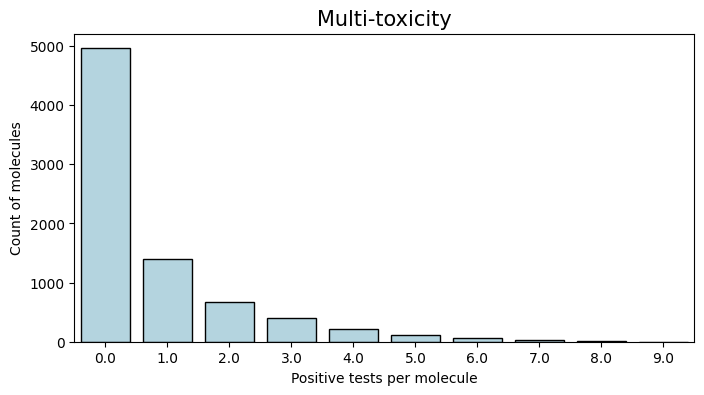

In [ ]:

tox21_df['n_toxicities'] = tox21_df[target_cols].sum(axis=1)

plt.figure(figsize=(8,4))
sns.countplot(data=tox21_df, x='n_toxicities', color="lightblue", edgecolor="black") 
plt.title('Multi-toxicity', fontsize=15)
plt.xlabel('Positive tests per molecule')
plt.ylabel('Count of molecules')
#plt.savefig(f"{RESULTS_PATH}/multi_toxicity.pdf", format="pdf", bbox_inches="tight")
plt.show()

## LogP & Molecular weight
Comparison between toxic and safe molecules, bot for LogP & Molecular weight.

[10:18:21] WARNING: not removing hydrogen atom without neighbors
[10:18:22] WARNING: not removing hydrogen atom without neighbors


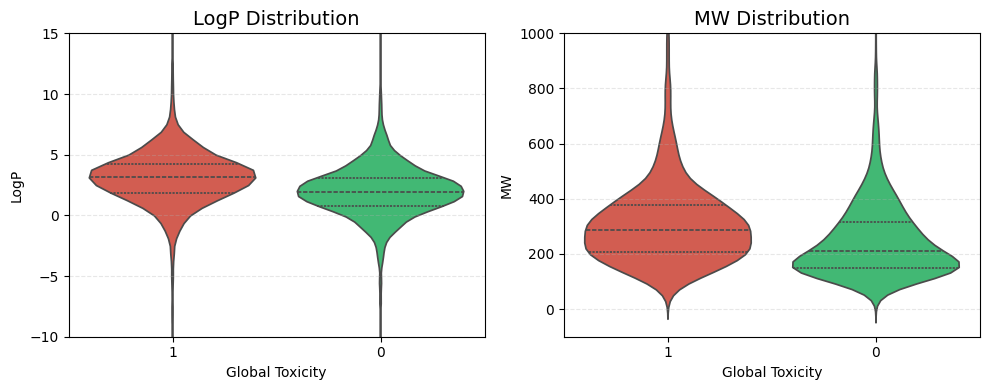

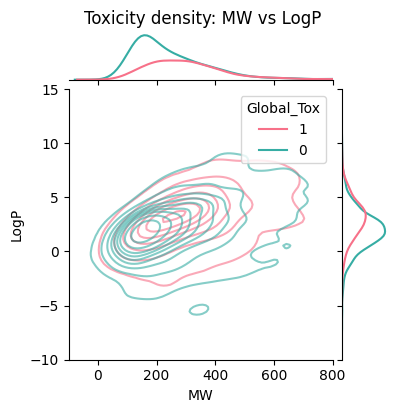

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Descriptors
import pandas as pd
from matplotlib.colors import ListedColormap


def get_mw(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return Descriptors.MolWt(mol) if mol else None

def get_logp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return Descriptors.MolLogP(mol) if mol else None

tox21_df['MW'] = tox21_df['smiles'].apply(get_mw)
tox21_df['LogP'] = tox21_df['smiles'].apply(get_logp)
tox21_df = tox21_df.dropna(subset=['MW', 'LogP'])


target_cols = [c for c in tox21_df.columns if c.startswith(('NR-', 'SR-'))]
tox21_df['Global_Tox'] = tox21_df[target_cols].max(axis=1).astype(int).astype(str)


fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.violinplot(
    data=tox21_df,
    x='Global_Tox',
    y='LogP',
    hue='Global_Tox',
    palette={'0': "#2ecc71", '1': "#e74c3c"},
    inner="quartile",
    dodge=False,
    ax=axes[0],
    legend=False
)
axes[0].set_title('LogP Distribution', fontsize=14)
axes[0].set_xlabel('Global Toxicity')
axes[0].set_ylabel('LogP')
axes[0].grid(axis='y', linestyle='--', alpha=0.3)


sns.violinplot(
    data=tox21_df,
    x='Global_Tox',
    y='MW',
    hue='Global_Tox',
    palette={'0': "#2ecc71", '1': "#e74c3c"},
    inner="quartile",
    dodge=False,
    ax=axes[1],
    legend=False
)
axes[1].set_title('MW Distribution', fontsize=14)
axes[1].set_xlabel('Global Toxicity')
axes[1].set_ylabel('MW')
axes[1].grid(axis='y', linestyle='--', alpha=0.3)
axes[0].set_ylim(-10, 15) 
axes[1].set_ylim(-100, 1000)

plt.tight_layout()
#plt.savefig(f"{RESULTS_PATH}/MW_LogP.pdf", format="pdf", bbox_inches="tight")
plt.show()


g = sns.jointplot(
    data=tox21_df,
    x='MW',
    y='LogP',
    hue='Global_Tox',
    kind='kde',
    palette='husl',
    alpha=0.6,
    height=4
)

g.fig.suptitle('Toxicity density: MW vs LogP', y=1.02)

g.ax_joint.set_xlim(-100, 800)
g.ax_joint.set_ylim(-10, 15)

#plt.savefig(f"{RESULTS_PATH}/MW_LogP_combined.pdf", format="pdf", bbox_inches="tight")
plt.show()




In [9]:
#show(tox21_df)
mean_mw = tox21_df['MW'].mean()
std_mw = tox21_df['MW'].std()
mean_logp = tox21_df['LogP'].mean()
std_logp = tox21_df['LogP'].std()

print(f"MW: Mean={mean_mw}, Std={std_mw}")
print(f"LogP: Mean={mean_logp}, Std={std_logp}")

MW: Mean=276.3186514635, Std=165.81763149230258
LogP: Mean=2.3656480296258473, Std=2.365317821127914


## H-bond
Here we represent the number of hydrogen bond donor and acceptor counts from SMILES.

[10:19:00] WARNING: not removing hydrogen atom without neighbors
[10:19:00] WARNING: not removing hydrogen atom without neighbors
[10:19:01] WARNING: not removing hydrogen atom without neighbors
[10:19:01] WARNING: not removing hydrogen atom without neighbors


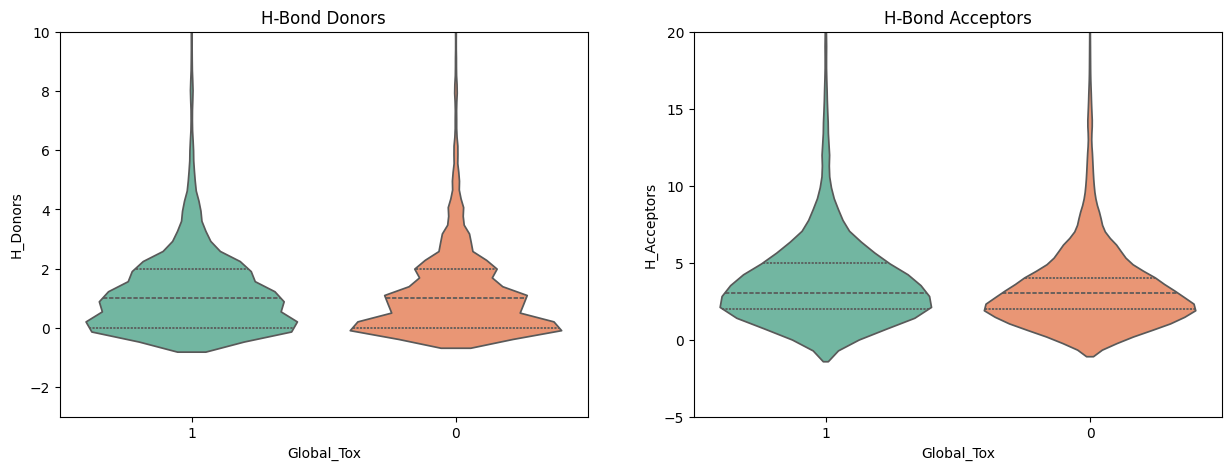

In [ ]:

tox21_df['H_Donors'] = tox21_df['smiles'].apply(lambda x: Descriptors.NumHDonors(Chem.MolFromSmiles(x)) if Chem.MolFromSmiles(x) else None)
tox21_df['H_Acceptors'] = tox21_df['smiles'].apply(lambda x: Descriptors.NumHAcceptors(Chem.MolFromSmiles(x)) if Chem.MolFromSmiles(x) else None)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.violinplot(
    data=tox21_df,
    x='Global_Tox',
    y='H_Donors',
    hue='Global_Tox',
    ax=axes[0],
    palette='Set2',
    inner='quartile'
)
axes[0].set_title('H-Bond Donors')

sns.violinplot(
    data=tox21_df,
    x='Global_Tox',
    y='H_Acceptors',
    hue='Global_Tox',
    ax=axes[1],
    palette='Set2',
    inner='quartile'
)
axes[1].set_title('H-Bond Acceptors')
axes[0].set_ylim(-3, 10) 
axes[1].set_ylim(-5, 20)   

#plt.savefig(f"{RESULTS_PATH}/H-bond.pdf", format="pdf", bbox_inches="tight")
plt.show()

## Enriching Dataset
Here we perform an enrichment of the Tox21 dataset with additive, informative for the model, features.

In [11]:
columns_to_save = ['smiles', 'MW', 'LogP'] + target_cols
subset_df = tox21_df[columns_to_save]
initial_len = len(subset_df)
subset_df = subset_df.dropna(subset=['MW', 'LogP'])
print(f"Removed {initial_len - len(subset_df)} non-valid SMILES.")

path = Path(DATASET_PATH)
path.parent.mkdir(parents=True, exist_ok=True)
# subset_df.to_csv(path, index=False)


print(f"File salvato con successo: {path}")
print(f"Dimensioni del file salvato: {subset_df.shape}")
print("-" * 30)
#print(subset_df.head())


Removed 0 non-valid SMILES.
File salvato con successo: datasets\tox21_processed_features.csv
Dimensioni del file salvato: (7831, 15)
------------------------------


# **EXTRA**
---



## Visualization

In [ ]:
def compare_molecules_3d(smiles_toxic, smiles_safe, name_toxic="Tossica", name_safe="Non Tossica"):
    
    # toxic
    mol_tox = Chem.MolFromSmiles(smiles_toxic)
    mol_tox = Chem.AddHs(mol_tox)
    AllChem.EmbedMolecule(mol_tox, AllChem.ETKDG())
    AllChem.MMFFOptimizeMolecule(mol_tox)
    block_tox = Chem.MolToMolBlock(mol_tox)

    # safe
    mol_safe = Chem.MolFromSmiles(smiles_safe)
    mol_safe = Chem.AddHs(mol_safe)
    AllChem.EmbedMolecule(mol_safe, AllChem.ETKDG())
    AllChem.MMFFOptimizeMolecule(mol_safe)
    block_safe = Chem.MolToMolBlock(mol_safe)

    # viewer
    view = py3Dmol.view(width=900, height=500, viewergrid=(1, 2))
    view.addModel(block_tox, 'mol', viewer=(0, 0))
    view.setStyle({'stick': {'colorscheme': 'redCarbon'}}, viewer=(0, 0)) 
    view.addLabel(name_toxic, {'position': {'x': -2, 'y': 5, 'z': 0}, 'backgroundColor': "#b93e3e", 'fontColor': 'black'}, viewer=(0, 0))
    view.addModel(block_safe, 'mol', viewer=(0, 1))
    view.setStyle({'stick': {'colorscheme': 'greenCarbon'}}, viewer=(0, 1))
    view.addLabel(name_safe, {'position': {'x': -2, 'y': 5, 'z': 0}, 'backgroundColor': "#6de26d", 'fontColor': 'black'}, viewer=(0, 1))
    view.zoomTo()
    view.show()


# Parathion
toxic_smiles = tox21_df["smiles"][0] 
# Aspirina
safe_smiles = tox21_df["smiles"][9] 


print("Showing comparison")
compare_molecules_3d(toxic_smiles, safe_smiles, name_toxic="l'Ethoxzolamide", name_safe="Ottanoato di zinco")

Showing comparison


[09:47:47] UFFTYPER: Unrecognized charge state for atom: 0
[09:47:47] UFFTYPER: Unrecognized atom type: Zn+2 (0)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.